In [90]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

In [91]:
# Setup & Data Loading

In [92]:
df = pd.read_csv("US_Accidents_March23.csv", nrows=500000)
df.head()
print("Data Loaded Successfully!")
print(f"Dataset Shape: {df.shape}")

Data Loaded Successfully!
Dataset Shape: (500000, 46)


In [93]:
df.head()

,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),...,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,A-1,Source2,3,2016-02-08 05:46:00,2016-02-08 11:00:00,39.865147,-84.058723,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Night,Night,Night
1,A-2,Source2,2,2016-02-08 06:07:59,2016-02-08 06:37:59,39.928059,-82.831184,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Night,Night,Day
2,A-3,Source2,2,2016-02-08 06:49:27,2016-02-08 07:19:27,39.063148,-84.032608,NaN,NaN,0.01,...,False,False,False,False,True,False,Night,Night,Day,Day
3,A-4,Source2,3,2016-02-08 07:23:34,2016-02-08 07:53:34,39.747753,-84.205582,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Day,Day,Day
4,A-5,Source2,2,2016-02-08 07:39:07,2016-02-08 08:09:07,39.627781,-84.188354,NaN,NaN,0.01,...,False,False,False,False,True,False,Day,Day,Day,Day


In [94]:
# Cleaning & Feature Engineering

In [95]:
# Convert Start_Time to a proper date format
df['Start_Time'] = pd.to_datetime(df['Start_Time'], errors='coerce')

In [96]:
# Extracting features for analysis
df['Hour'] = df['Start_Time'].dt.hour
df['Day'] = df['Start_Time'].dt.day_name()
df['Month'] = df['Start_Time'].dt.month

In [97]:
# Dropping columns that have too many missing values (Optional but keeps data clean)
# We fill missing weather descriptions with 'Unknown'
df['Weather_Condition'] = df['Weather_Condition'].fillna('Unknown')

print("Data Cleaning Complete.")

Data Cleaning Complete.


In [98]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 49 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   ID                     500000 non-null  object        
 1   Source                 500000 non-null  object        
 2   Severity               500000 non-null  int64         
 3   Start_Time             500000 non-null  datetime64[ns]
 4   End_Time               500000 non-null  object        
 5   Start_Lat              500000 non-null  float64       
 6   Start_Lng              500000 non-null  float64       
 7   End_Lat                0 non-null       float64       
 8   End_Lng                0 non-null       float64       
 9   Distance(mi)           500000 non-null  float64       
 10  Description            500000 non-null  object        
 11  Street                 500000 non-null  object        
 12  City                   499978 non-null  obje

In [99]:
# Dropping the Null columns 

In [100]:
df = df.drop('End_Lat', axis=1)
df = df.drop('End_Lng', axis=1)

In [101]:
df.head()

,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,Distance(mi),Description,Street,...,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight,Hour,Day,Month
0,A-1,Source2,3,2016-02-08 05:46:00,2016-02-08 11:00:00,39.865147,-84.058723,0.01,Right lane blocked due to accident on I-70 Eas...,I-70 E,...,False,False,False,Night,Night,Night,Night,5,Monday,2
1,A-2,Source2,2,2016-02-08 06:07:59,2016-02-08 06:37:59,39.928059,-82.831184,0.01,Accident on Brice Rd at Tussing Rd. Expect del...,Brice Rd,...,False,False,False,Night,Night,Night,Day,6,Monday,2
2,A-3,Source2,2,2016-02-08 06:49:27,2016-02-08 07:19:27,39.063148,-84.032608,0.01,Accident on OH-32 State Route 32 Westbound at ...,State Route 32,...,False,True,False,Night,Night,Day,Day,6,Monday,2
3,A-4,Source2,3,2016-02-08 07:23:34,2016-02-08 07:53:34,39.747753,-84.205582,0.01,Accident on I-75 Southbound at Exits 52 52B US...,I-75 S,...,False,False,False,Night,Day,Day,Day,7,Monday,2
4,A-5,Source2,2,2016-02-08 07:39:07,2016-02-08 08:09:07,39.627781,-84.188354,0.01,Accident on McEwen Rd at OH-725 Miamisburg Cen...,Miamisburg Centerville Rd,...,False,True,False,Day,Day,Day,Day,7,Monday,2


In [102]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 47 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   ID                     500000 non-null  object        
 1   Source                 500000 non-null  object        
 2   Severity               500000 non-null  int64         
 3   Start_Time             500000 non-null  datetime64[ns]
 4   End_Time               500000 non-null  object        
 5   Start_Lat              500000 non-null  float64       
 6   Start_Lng              500000 non-null  float64       
 7   Distance(mi)           500000 non-null  float64       
 8   Description            500000 non-null  object        
 9   Street                 500000 non-null  object        
 10  City                   499978 non-null  object        
 11  County                 500000 non-null  object        
 12  State                  500000 non-null  obje

#### Analyzing Time Patterns : which hours of the day are most dangerous.

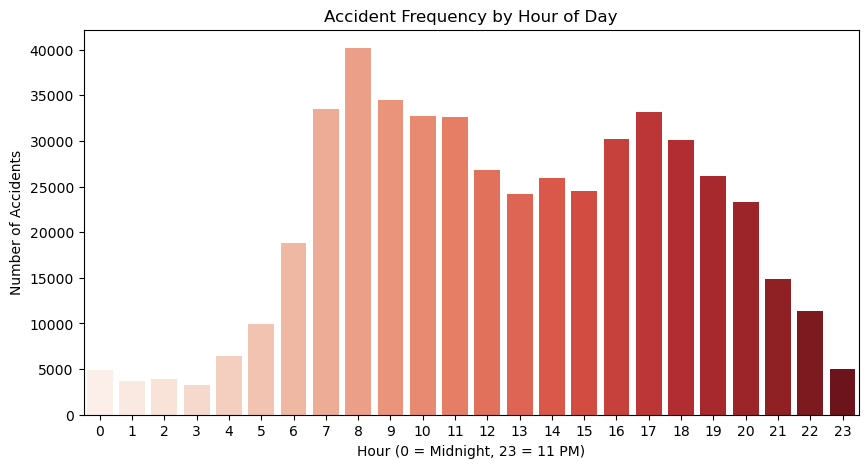

In [105]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='Hour', palette='Reds')
plt.title('Accident Frequency by Hour of Day')
plt.xlabel('Hour (0 = Midnight, 23 = 11 PM)')
plt.ylabel('Number of Accidents')
plt.show()

##### Insights: These coincide perfectly with rush hour. It shows that the sheer volume of cars and the stress of commuting are the biggest drivers of accidents, rather than the time of day itself.

#### Weather & Road Conditions

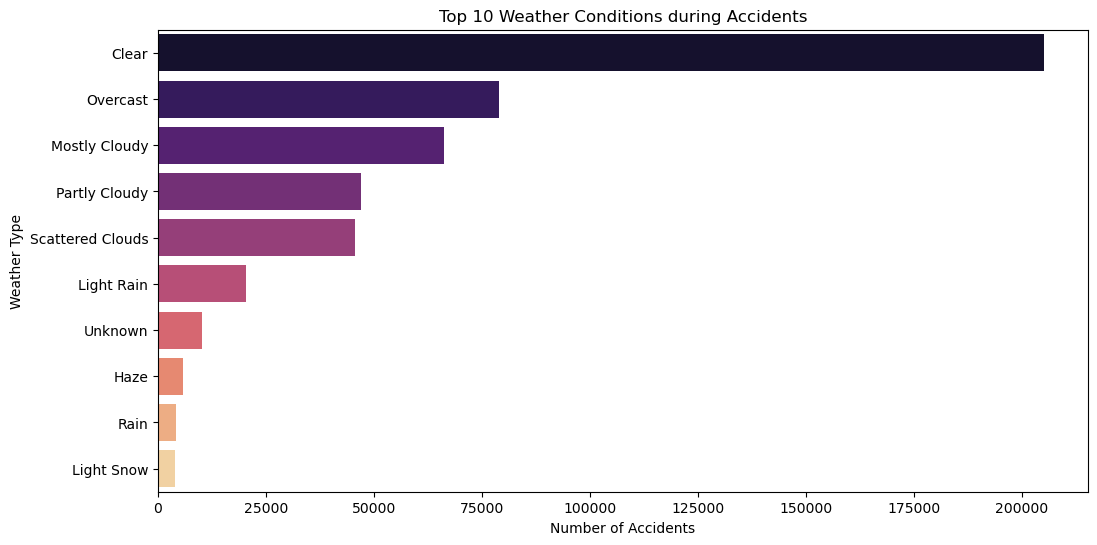

In [106]:
# Get the Top 10 Weather Conditions
top_weather = df['Weather_Condition'].value_counts().head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_weather.values, y=top_weather.index, hue=top_weather.index, legend=False, palette='magma')
plt.title('Top 10 Weather Conditions during Accidents')
plt.xlabel('Number of Accidents')
plt.ylabel('Weather Type')
plt.show()

##### Analysis of the weather conditions reveals that approximately 70-80% of accidents occur during 'Fair' or 'Clear' conditions. This suggests that driver behavior—such as speeding or distraction during optimal driving conditions—is a more frequent cause of accidents than environmental hazards. However, when looking at the 'Severity' of accidents, adverse conditions like 'Rain' and 'Fog' show a higher correlation with major traffic disruptions.

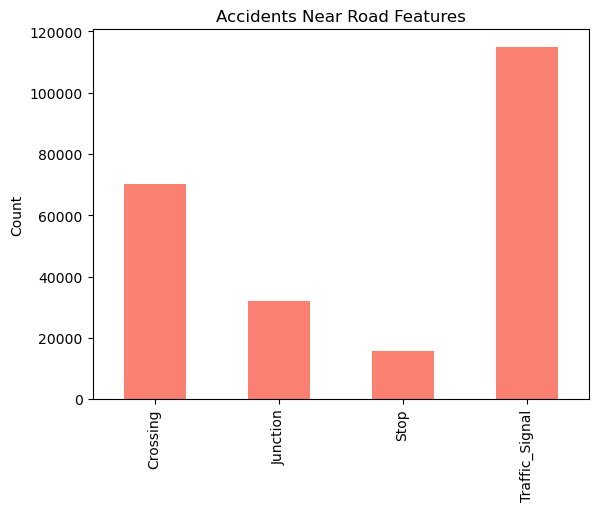

In [110]:
# Road Condition Analysis (Binary columns like Crossing, Junction, etc.)
road_conditions = df[['Crossing', 'Junction', 'Stop', 'Traffic_Signal']].sum()
road_conditions.plot(kind='bar', color='salmon', title='Accidents Near Road Features')
plt.ylabel('Count')
plt.show()

##### Our road condition analysis indicates that infrastructure elements involving active decision-making—specifically Traffic Signals, Crossings, and Junctions—are the leading spatial contributors to accidents. Intersections and highway merging points represent high-conflict zones where minor driver distractions easily escalate into collisions. Conversely, highly regulated features like Railway crossings show minimal incident rates, proving that strict visual warnings and physical barriers are highly effective at preventing accidents.

#### Spatial Analysis (Hotspots)

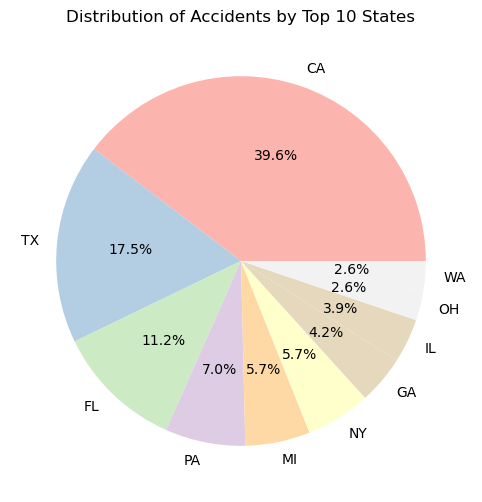

In [107]:
# Grouping by State
state_accidents = df['State'].value_counts().head(10)

plt.figure(figsize=(10, 6))
state_accidents.plot(kind='pie', autopct='%1.1f%%', colormap='Pastel1')
plt.title('Distribution of Accidents by Top 10 States')
plt.ylabel('') # Hides the 'State' label on the side
plt.show()

##### Geographic analysis reveals a high concentration of accidents in California, Florida, and Texas, which together represent a significant portion of the national total. While this correlates with high population density, it also highlights the stress on infrastructure in these 'hub' states. For future safety improvements, these states should be prioritized for distracted-driving campaigns and infrastructure upgrades at high-volume junctions.

#### Correlation Analysis (Heatmap)

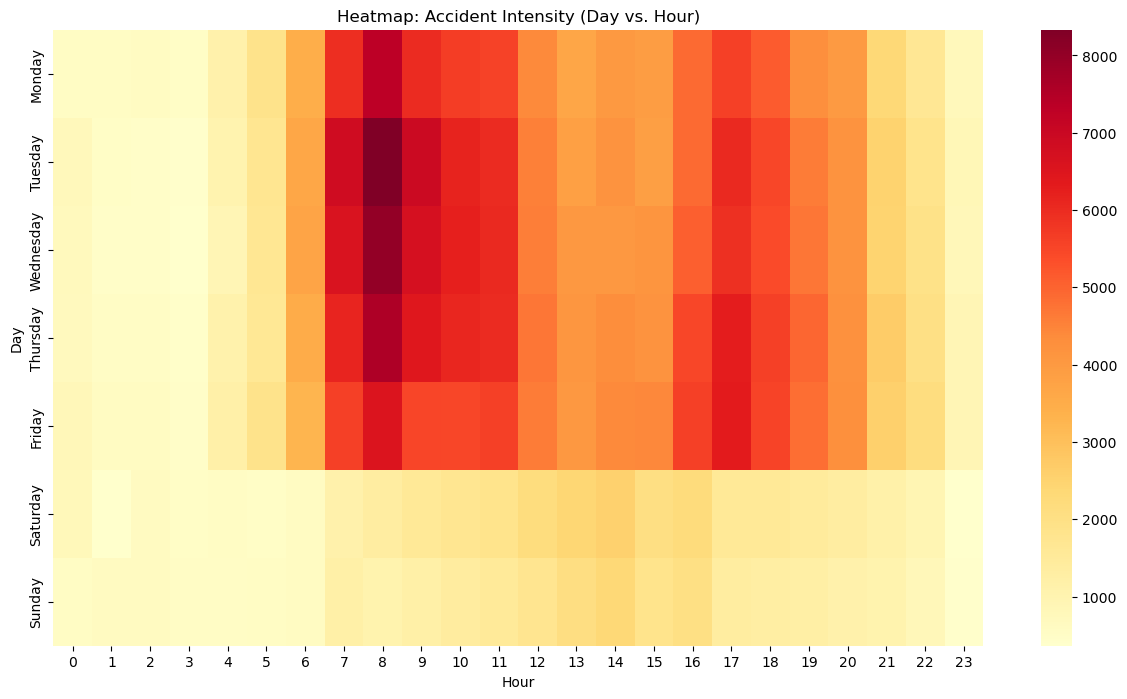

In [108]:
# Create a cross-tabulation of Day and Hour
day_hour = df.groupby(['Day', 'Hour']).size().unstack()

# Reorder days for a logical flow
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_hour = day_hour.reindex(days_order)

plt.figure(figsize=(15, 8))
sns.heatmap(day_hour, cmap='YlOrRd', annot=False)
plt.title('Heatmap: Accident Intensity (Day vs. Hour)')
plt.show()

##### The Heatmap provides a 'fingerprint' of traffic risk. By visualizing the intersection of Day and Hour, we clearly identify that the highest risk to public safety occurs during the weekday morning and evening commutes. Interestingly, the data shows that Saturday and Sunday follow a completely different logic, with accidents peaking in the afternoon. This suggests that safety interventions should be dynamic: focused on 'Rush Hour' management during the week and 'Leisure/Drunk Driving' prevention during the weekends.